Realiza un programa en jupyter con python, en el cual haciendo uso del RETO DEL RELOJ (identificando cualquier hora analógica), me responda la hora de manera literal 

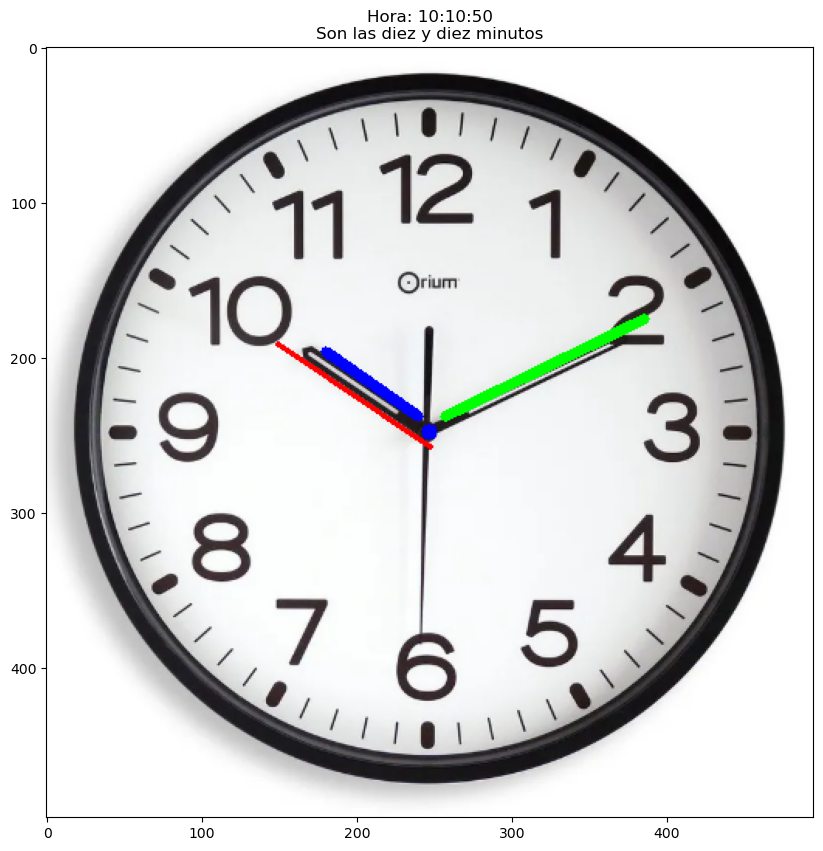

Hora detectada: 10:10:50
En palabras: Son las diez y diez minutos


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import num2words

def hora_literal_espanol(hora, minutos):
   
    # Ajustar la hora para expresiones como "es la una" vs "son las dos, tres, etc."
    hora_real = hora if hora != 0 else 12  # Convertir 0 a 12
    
    # Expresiones especiales para ciertos minutos
    if minutos == 0:
        if hora_real == 1:
            return f"Es la una en punto"
        else:
            return f"Son las {num2words.num2words(hora_real, lang='es')} en punto"
    elif minutos == 15:
        if hora_real == 1:
            return f"Es la una y cuarto"
        else:
            return f"Son las {num2words.num2words(hora_real, lang='es')} y cuarto"
    elif minutos == 30:
        if hora_real == 1:
            return f"Es la una y media"
        else:
            return f"Son las {num2words.num2words(hora_real, lang='es')} y media"
    elif minutos == 45:
        hora_siguiente = (hora_real + 1) if (hora_real + 1) <= 12 else 1
        if hora_siguiente == 1:
            return f"Es un cuarto para la una"
        else:
            return f"Son las menos cuarto para las {num2words.num2words(hora_siguiente, lang='es')}"
    elif minutos > 30:
        # Para minutos mayores a 30, es común expresarlo como "menos" hacia la hora siguiente
        minutos_restantes = 60 - minutos
        hora_siguiente = (hora_real + 1) if (hora_real + 1) <= 12 else 1
        
        if hora_siguiente == 1:
            return f"Faltan {num2words.num2words(minutos_restantes, lang='es')} minutos para la una"
        else:
            return f"Faltan {num2words.num2words(minutos_restantes, lang='es')} minutos para las {num2words.num2words(hora_siguiente, lang='es')}"
    else:
        # Para otros minutos, usamos la forma "y minutos"
        if hora_real == 1:
            return f"Es la una y {num2words.num2words(minutos, lang='es')} minutos"
        else:
            return f"Son las {num2words.num2words(hora_real, lang='es')} y {num2words.num2words(minutos, lang='es')} minutos"

def formato_hora_digital(hora, minutos, segundos):
    """
    Formatea la hora en formato digital (HH:MM:SS).
    """
    # Asegurarse de que la hora sea de 12 horas
    hora_12 = hora if hora != 0 else 12
    return f"{hora_12}:{minutos:02d}:{segundos:02d}"

def imagen_Relog(imagen_bgr):
    imagen_rgb = cv2.cvtColor(imagen_bgr,cv2.COLOR_BGR2RGB)
    gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    gris = cv2.GaussianBlur(gris, (5, 5), 1)
    gris = cv2.equalizeHist(gris)
    imgNorm=cv2.normalize(gris,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
    bordes = cv2.Canny(imgNorm, 50, 150)
    lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)
    centro_x = imagen_bgr.shape[1] // 2
    centro_y = imagen_bgr.shape[0] // 2
    def calcular_angulo(x1, y1, x2, y2):
        dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
        dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
        if dist1 > dist2:
            dx = x1 - centro_x
            dy = centro_y - y1
        else:
            dx = x2 - centro_x
            dy = centro_y - y2
        angulo = np.degrees(np.arctan2(dy, dx))
        angulo = (90 - angulo) % 360
        return angulo
    manecillas = []
    if lineas is not None:
        for linea in lineas:
            x1, y1, x2, y2 = linea[0]
            longitud = np.hypot(x2 - x1, y2 - y1)
            distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))

            if distancia_centro < 100 and 30 < longitud < 300:
                angulo = calcular_angulo(x1, y1, x2, y2)
                manecillas.append({
                    'puntos': (x1, y1, x2, y2),
                    'longitud': longitud,
                    'angulo': angulo
                })

    if len(manecillas) >= 3:
        # CORTO LARGO
        manecillas.sort(key=lambda x: x['longitud'])
        horario = manecillas[-5]
        minutero = manecillas[-2]
        segundero = manecillas[-3]
        
        hora = int((horario['angulo'] / 30) % 12)
        minutos = int((minutero['angulo'] / 6) % 60)
        segundos = int((segundero['angulo'] / 6) % 60)

        fraccion_hora = (horario['angulo'] / 30) % 12
        if abs(fraccion_hora - hora) > 0.5:
            hora = (hora + 1) % 12

        imagen_resultado = imagen_rgb.copy()
        cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
        cv2.line(imagen_resultado, (horario['puntos'][0], horario['puntos'][1]), (horario['puntos'][2], horario['puntos'][3]), (0, 0, 255), 5)  # hora azul
        cv2.line(imagen_resultado, (minutero['puntos'][0], minutero['puntos'][1]), (minutero['puntos'][2], minutero['puntos'][3]), (0, 255, 0), 5)  # minutos verde
        cv2.line(imagen_resultado, (segundero['puntos'][0], segundero['puntos'][1]), (segundero['puntos'][2], segundero['puntos'][3]), (255, 0, 0), 2)  # segundos rojo

        # Crear la expresión literal de la hora
        hora_digital = formato_hora_digital(hora, minutos, segundos)
        expresion_literal = hora_literal_espanol(hora, minutos)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(imagen_resultado)
        plt.title(f'Hora: {hora_digital}\n{expresion_literal}')
        plt.show()
        
        # Devuelve los resultados para posible uso posterior
        return {
            'hora': hora,
            'minutos': minutos,
            'segundos': segundos,
            'hora_digital': hora_digital,
            'expresion_literal': expresion_literal
        }
    
    return None

# Ejemplo de uso
if __name__ == "__main__":
    imagen_bgr = cv2.imread('img/reloj6.png')
    resultado = imagen_Relog(imagen_bgr)
    if resultado:
        print(f"Hora detectada: {resultado['hora_digital']}")
        print(f"En palabras: {resultado['expresion_literal']}")